<a href="https://colab.research.google.com/github/aahan-charak24/Deep-Learning-Mastery/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

<h2>1-d Linear regression, y = mx</h2>


In [7]:
# y = mx

#make tensor get automatic number of rows from data and one column
X = torch.arange(-10, 10, 0.1).view(-1, 1)

func = -5 * X

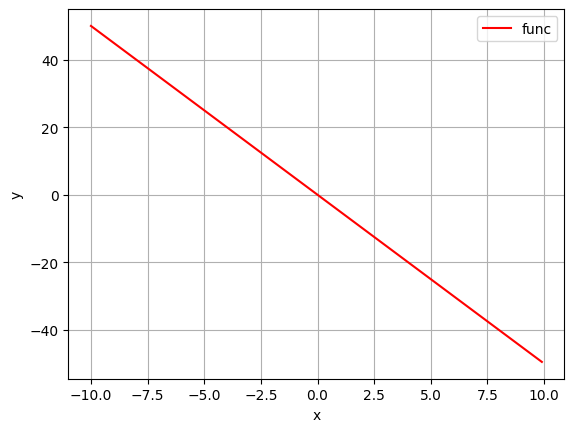

In [10]:
plt.plot(X.numpy(), func.numpy(), 'r', label = 'func')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()

In [12]:
#add gaussian noise
Y = func + 0.4 * torch.rand(X.size())

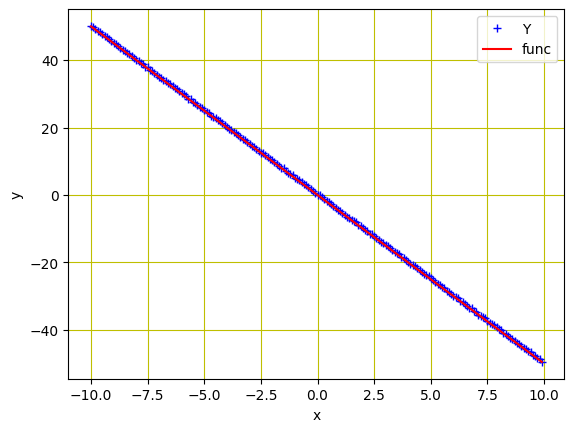

In [14]:
plt.plot(X.numpy(), Y.numpy(), 'b+', label = 'Y')
plt.plot(X.numpy(), func.numpy(), 'r', label  = 'func')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid('True', color = 'y')
plt.show()

In [38]:
w = torch.tensor(-7.0, requires_grad=True)

#forward pass
def forward(x):
  return w * x

#mean squared error
def criterion(y_pred, y):
  return torch.mean((y_pred - y)**2)

#parameters
lr = 0.001
loss_list = []
epochs = 10

#run for n epochs
for i in range(epochs):
  #get the predictions
  Y_pred = forward(X)
  #get the losse
  loss = criterion(Y_pred, Y)
  #append to list
  loss_list.append(loss.item())
  #backward pass to calc gradients
  loss.backward()
  #update the weight
  w.data = w.data - lr * w.grad.data
  #zero the gradients after each epoch
  w.grad.data.zero_()
  #print at the end of epoch
  print(f'epoch: {i+1} loss : {loss} weight: {w}')



epoch: 1 loss : 135.5643310546875 weight: -6.968744277954102
epoch: 2 loss : 134.59555053710938 weight: -6.938009738922119
epoch: 3 loss : 133.65882873535156 weight: -6.907787799835205
epoch: 4 loss : 132.75308227539062 weight: -6.87807035446167
epoch: 5 loss : 131.87730407714844 weight: -6.848848342895508
epoch: 6 loss : 131.03050231933594 weight: -6.820113658905029
epoch: 7 loss : 130.21173095703125 weight: -6.791858196258545
epoch: 8 loss : 129.42001342773438 weight: -6.764074325561523
epoch: 9 loss : 128.6544952392578 weight: -6.736753940582275
epoch: 10 loss : 127.91431427001953 weight: -6.709888935089111


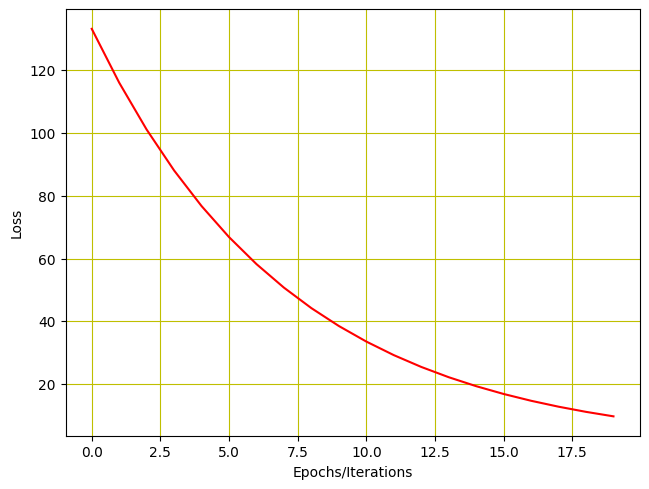

In [24]:
plt.plot(loss_list, 'r')
plt.tight_layout()
plt.grid('True', color = 'y')
plt.xlabel('Epochs/Iterations')
plt.ylabel('Loss')
plt.show()

<h2>1-d Linear Regression: y = $Φ_0 + Φ_1 * x$</h2>

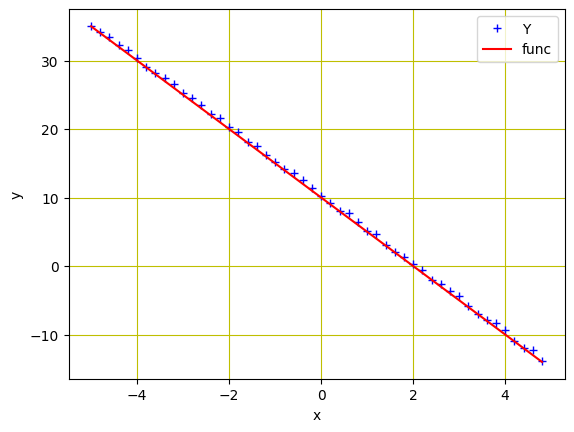

In [37]:
X = torch.arange(-5.0, 5.0, 0.2).view(-1, 1)

func = -5 * X + 10

Y = func + 0.7* torch.rand(X.size())

plt.plot(X.numpy(), Y.numpy(), 'b+', label = 'Y')
plt.plot(X.numpy(), func.numpy(), 'r', label = 'func')
plt.xlabel('x')
plt.ylabel('y')
plt.grid('True', color = 'y')
plt.legend()
plt.show()

In [67]:
import math
phi_0 = torch.tensor(40.0, requires_grad = True)
phi_1 = torch.tensor(-6.0, requires_grad = True)
phi_0_star = phi_0.item()
phi_1_star = phi_1.item()
lowest_loss = math.inf
y_pred = []
#forward
def forward(x, phi_0, phi_1):
  return phi_0 + phi_1 * x

#criterion
def loss(y_pred, y):
  return torch.mean((y_pred-y)**2)


#parameters
epochs = 1000
lr = 0.01
loss_list = []
verbose = False

for i in range(epochs):
  #forward pass
  Y_pred = forward(X, phi_0, phi_1)
  y_pred.append(Y_pred.detach())

  #backward pass
  loss_val = loss(Y_pred, Y)
  loss_list.append(loss_val.item())

  loss_val.backward()

  #update weights
  phi_0.data = phi_0.data - lr * phi_0.grad.data
  phi_1.data = phi_1.data - lr * phi_1.grad.data

  if(loss_val.item() < lowest_loss):
    lowest_loss = loss_val.item()
    phi_0_star = phi_0.item()
    phi_1_star = phi_1.item()

  phi_0.grad.data.zero_()
  phi_1.grad.data.zero_()

  if verbose:
    #print loss
    print(f'epoch: {i+1} loss: {loss_val}')







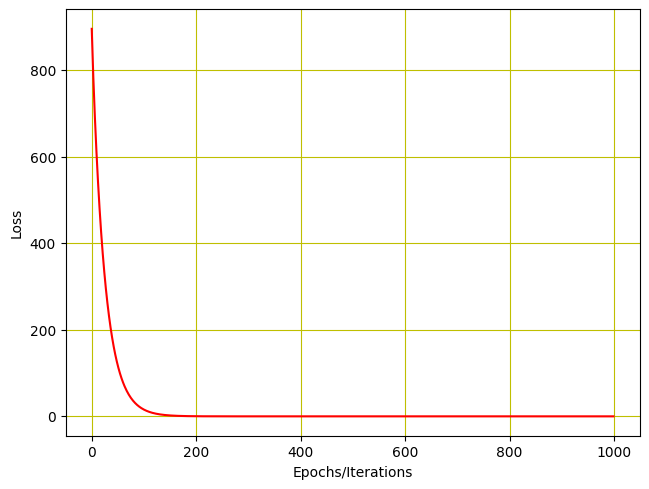

In [68]:
plt.plot(loss_list, 'r')
plt.tight_layout()
plt.grid('True', color = 'y')
plt.xlabel('Epochs/Iterations')
plt.ylabel('Loss')
plt.show()

In [69]:
#predictions
y_pred = forward(X, phi_0_star, phi_1_star)
y_pred = y_pred.detach().numpy()

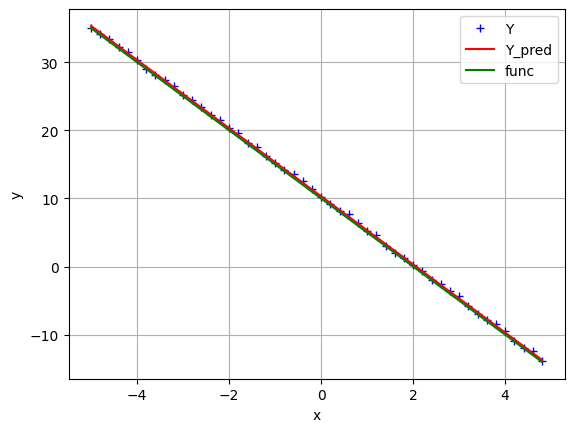

In [70]:
plt.plot(X.numpy(), Y.numpy(), 'b+', label = 'Y')
plt.plot(X.numpy(), y_pred, 'r', label = 'Y_pred')
plt.plot(X.numpy(), func.numpy(), 'g', label = 'func')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()